In [1]:
import pandas as pd

# Read data
df = pd.read_excel('temperature_data.xlsx')
df.head()

,Chips,Temperature_Celsius
0,44.0,26.944
1,46.4,25.833
2,43.6,25.556
3,35.0,23.056
4,35.0,21.389


In [6]:
# Convert the 'Chips' column of the DataFrame into a NumPy array
Chips = df['Chips'].to_numpy()

# Convert the 'Temperature_Celsius' column of the DataFrame into a NumPy array
Temperature_Celsius = df['Temperature_Celsius'].to_numpy()

In [7]:
Chips

array([44.   , 46.4  , 43.6  , 35.   , 35.   , 32.6  , 28.9  , 27.7  ,
       25.5  , 20.375, 12.5  , 37.   , 37.5  , 36.5  , 36.2  , 33.   ,
       43.   , 46.   , 29.   , 31.7  , 31.   , 28.75 , 23.5  , 32.4  ,
       31.   , 29.5  , 22.5  , 20.6  , 35.   , 33.1  , 31.5  , 28.8  ,
       21.3  , 37.8  , 37.   , 37.1  , 36.2  , 31.4  , 30.2  , 31.3  ,
       26.1  , 25.2  , 23.66 , 22.25 , 17.5  , 15.5  , 14.75 , 15.   ,
       14.   , 18.5  , 27.7  , 26.   , 21.7  , 12.5  , 12.5  ])

In [8]:
Temperature_Celsius

array([26.944 , 25.833 , 25.556 , 23.056 , 21.389 , 20.    , 18.889 ,
       18.333 , 16.389 , 13.889 , 12.778 , 24.583 , 23.333 , 23.333 ,
       22.5   , 18.889 , 25.278 , 25.833 , 20.278 , 20.278 , 20.    ,
       18.889 , 15.    , 21.111 , 20.556 , 19.444 , 16.25  , 14.722 ,
       22.222 , 21.667 , 20.556 , 19.167 , 15.556 , 23.889 , 22.917 ,
       22.5   , 21.111 , 19.722 , 18.889 , 20.556 , 17.222 , 17.222 ,
       16.111 , 16.667 , 13.611 , 12.778 , 11.111 , 11.667 , 10.    ,
       11.111 , 18.333 , 17.222 , 15.    , 10.417 ,  9.5833])

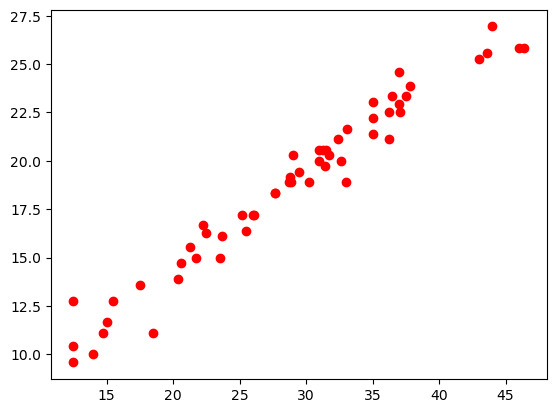

In [24]:
# Import the Matplotlib library for plotting
import matplotlib.pyplot as plt 

# Assign the 'Chips' data to the x-axis
x_val = Chips

# Assign the 'Temperature_Celsius' data to the y-axis
y_val = Temperature_Celsius

# Plot the data as red circles ('ro' stands for red color and circle marker)
plt.plot(x_val, y_val, 'ro')

# Display the plot
plt.show()

In [25]:
from statistics import mean
import numpy as np

def best_fit_slope_and_intercept(x, y):
    # Calculate the slope (m) using the best-fit line formula
    m = ((mean(x_val) * mean(y_val) - mean(x_val * y_val)) /
         (mean(x_val)**2 - mean(x_val * x_val)))
    
    # Calculate the y-intercept (b) using the slope and mean of x and y
    b = mean(y_val) - m * mean(x_val)
    
    return m, b

# Calculate slope and intercept for the data
m, b = best_fit_slope_and_intercept(x_val, y_val)
print("m = {}, b = {}".format(m, b))

m = 0.49543811977958857, b = 4.458638516454446


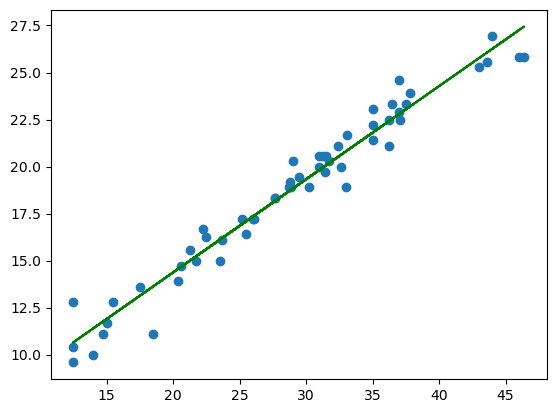

In [27]:
# Create the best-fit line by applying the linear equation (y = mx + b) to each x-value
regression_line = [(m * x_val) + b for x_val in x]

# Create a scatter plot of the original data points
plt.scatter(x_val, y_val)

# Plot the best-fit line based on the calculated slope and intercept
plt.plot(x, regression_line, color='green')

# Display the plot
plt.show()

In [35]:
import tensorflow as tf
keras = tf.keras

In [48]:
from tensorflow.keras.models import Sequential  # Import Sequential, a linear stack of layers for easy model building
from tensorflow.keras.layers import Dense       # Import Dense, a fully connected neural network layer

In [47]:
model.compile(
    loss='mean_squared_error',              # Specifies the loss function
    optimizer = tf.keras.optimizers.Adam(0.1)  # Creates an Adam optimizer with a learning rate of 0.1
)

This code compiles a model in TensorFlow/Keras, setting the criteria it will use to update weights during training. Here's a breakdown of the components:

1. `model.compile()`: This method prepares the model for training by specifying the loss function and optimizer. After compiling, the model can be trained using data.

2. `loss='mean_squared_error'`: 
   - The loss function measures the difference between the model's predictions and the actual target values.
   - `'mean_squared_error'` is commonly used in regression tasks. It calculates the average of the squared differences between the predicted and actual values, emphasizing larger errors and penalizing them more heavily. Lower values mean the model's predictions are closer to the actual targets.

3. `optimizer = tf.keras.optimizers.Adam(0.1)`:
   - Optimizer: The optimizer updates the model's weights to minimize the loss function.
   - Adam is a popular optimization algorithm in deep learning that combines features from the RMSprop and SGD optimizers. It adapts the learning rate for each parameter, making it effective in practice for various tasks.
   - Learning rate (0.1): This controls how much to adjust the model weights with respect to the gradient. A rate of `0.1` is relatively high, often used in early experimentation but may need adjusting based on how the model performs during training.

Together, this configuration sets the model to minimize prediction errors using mean squared error and updates weights through the Adam optimizer with a learning rate of `0.1`.

In [44]:
history = model.fit(x_val, y_val, epochs=500, verbose=True)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4308.5132 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 3587.0706  
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 2748.75348
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 2371.6218  
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 1786.9860  
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 1333.3046  
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 897.2834
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 646.6262
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 396.2710
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 231.8874
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 117.7658  
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 48.56676
Epoch 13/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 11.95491
Epoch 14/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7008 
Epoch 15/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 6.4653

This line trains the `model` on the input data:

- `history = model.fit(...)`: Trains the model and saves the training history (loss and other metrics over each epoch) in the variable `history`.

- `x_val, y_val`: `x_val` contains the input data, and `y_val` contains the corresponding target (label) data.

- `epochs=500`: Specifies the number of training cycles, or **epochs**. Here, the model will train for 500 epochs.

- `verbose=True`: Displays training progress in the output, including the loss after each epoch.

In [45]:
input_data = np.array([[34]])
prediction = model.predict(input_data)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[[21.395945]]
